In [12]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

In [13]:
TICKER     = "RELIANCE.NS"
START      = "2015-01-01"
END        = "2024-12-31"
SEQ_LEN    = 30
BATCH_SIZE = 32
EPOCHS     = 150
LR         = 0.0005
HIDDEN     = 64
LAYERS     = 2
DROPOUT    = 0.2
PATIENCE   = 20

In [14]:
print(f"Downloading {TICKER} ...")
df = yf.download(TICKER, start=START, end=END, auto_adjust=True)
df.dropna(inplace=True)
print(f"Rows: {len(df)}  |  {df.index[0].date()} → {df.index[-1].date()}")

# Use returns instead of raw price — stationary signal, easier to learn
close = df['Close'].values.reshape(-1, 1).astype(np.float32)

scaler      = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(close)

[*********************100%***********************]  1 of 1 completed

Rows: 2466  |  2015-01-01 → 2024-12-30


In [15]:
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = create_sequences(data_scaled, SEQ_LEN)
print(f"X: {X.shape} | y: {y.shape}")

X: (2436, 30, 1) | y: (2436, 1)


In [16]:
n         = len(X)
train_end = int(0.75 * n)
val_end   = int(0.88 * n)

X_train, y_train = torch.tensor(X[:train_end]),       torch.tensor(y[:train_end])
X_val,   y_val   = torch.tensor(X[train_end:val_end]),torch.tensor(y[train_end:val_end])
X_test,  y_test  = torch.tensor(X[val_end:]),          torch.tensor(y[val_end:])

# KEY FIX: DataLoader for proper mini-batch training
train_loader = DataLoader(TensorDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 1827 | Val: 316 | Test: 293


In [17]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = 1,
            hidden_size = HIDDEN,
            num_layers  = LAYERS,
            batch_first = True,
            dropout     = DROPOUT if LAYERS > 1 else 0,
        )
        self.norm = nn.LayerNorm(HIDDEN)
        self.head = nn.Sequential(
            nn.Linear(HIDDEN, 32),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = self.norm(out[:, -1, :])   # last timestep + normalize
        return self.head(out)

model     = LSTMModel()
criterion = nn.MSELoss()                    # MSE works better here than Huber
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"Params: {sum(p.numel() for p in model.parameters()):,}")

Params: 52,673


In [18]:
train_losses, val_losses = [], []
best_val, best_state, no_improve = float('inf'), None, 0

for epoch in range(1, EPOCHS + 1):
    # --- train ---
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    # --- validate ---
    model.eval()
    val_batch = []
    with torch.no_grad():
        for xb, yb in val_loader:
            val_batch.append(criterion(model(xb), yb).item())
    val_loss = np.mean(val_batch)

    scheduler.step()
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val:
        best_val   = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stop at epoch {epoch}  (best val: {best_val:.6f})")
            break

    if epoch % 25 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

model.load_state_dict(best_state)
print("Best weights restored.")

Epoch   1 | Train: 0.038235 | Val: 0.006489
Epoch  25 | Train: 0.003544 | Val: 0.001096
Epoch  50 | Train: 0.002748 | Val: 0.003069
Early stop at epoch 59  (best val: 0.000295)
Best weights restored.


In [19]:
model.eval()
with torch.no_grad():
    preds_scaled = model(X_test).numpy()

predictions = scaler.inverse_transform(preds_scaled)
y_actual    = scaler.inverse_transform(y_test.numpy())

mae  = mean_absolute_error(y_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_actual, predictions))
r2   = r2_score(y_actual, predictions)
mape = np.mean(np.abs((y_actual - predictions) / (y_actual + 1e-8))) * 100

print(f"\n{'─'*38}")
print(f"  Ticker : {TICKER}")
print(f"  MAE    : ₹{mae:.2f}")
print(f"  RMSE   : ₹{rmse:.2f}")
print(f"  R²     : {r2:.4f}")
print(f"  MAPE   : {mape:.2f}%")
print(f"{'─'*38}")


──────────────────────────────────────
  Ticker : RELIANCE.NS
  MAE    : ₹65.19
  RMSE   : ₹77.74
  R²     : 0.5608
  MAPE   : 4.53%
──────────────────────────────────────


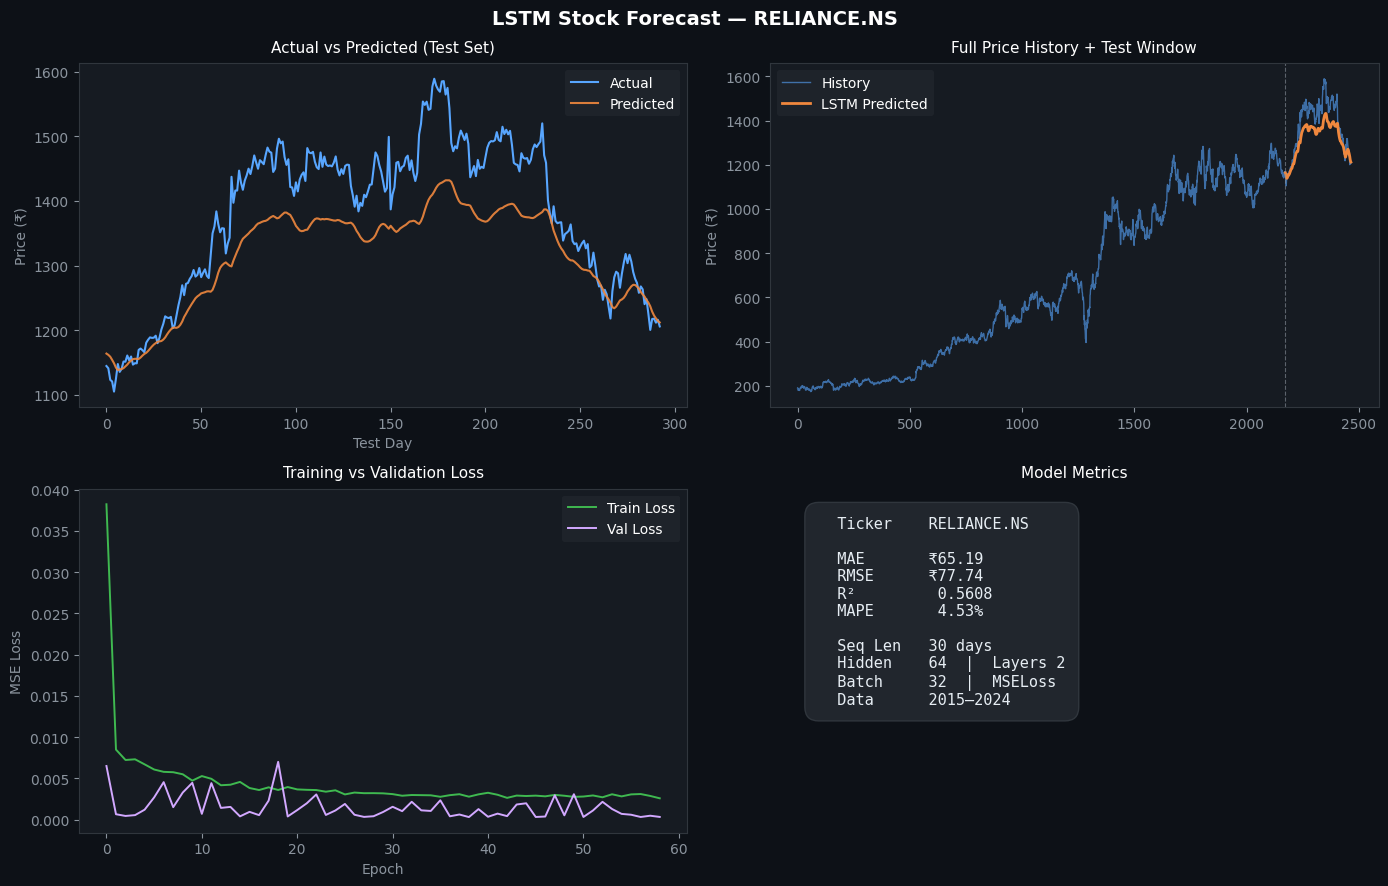

Saved → lstm_fixed.png


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor('#0d1117')
fig.suptitle(f'LSTM Stock Forecast — {TICKER}', color='white',
             fontsize=14, fontweight='bold', y=0.98)

C = {'actual': '#58a6ff', 'pred': '#f0883e', 'train': '#3fb950', 'val': '#d2a8ff'}

def style(ax, title):
    ax.set_facecolor('#161b22')
    ax.set_title(title, color='white', fontsize=11, pad=8)
    ax.tick_params(colors='#8b949e')
    for s in ax.spines.values():
        s.set_color('#30363d')

# Panel 1 — Actual vs Predicted
ax = axes[0, 0]
style(ax, 'Actual vs Predicted (Test Set)')
ax.plot(y_actual,    color=C['actual'], lw=1.5, label='Actual')
ax.plot(predictions, color=C['pred'],   lw=1.5, label='Predicted', alpha=0.9)
ax.legend(facecolor='#21262d', edgecolor='none', labelcolor='white')
ax.set_ylabel('Price (₹)', color='#8b949e')
ax.set_xlabel('Test Day', color='#8b949e')

# Panel 2 — Full history + prediction window
ax = axes[0, 1]
style(ax, 'Full Price History + Test Window')
full = df['Close'].values
ax.plot(full, color=C['actual'], lw=1, alpha=0.6, label='History')
offset = len(full) - len(predictions)
ax.plot(range(offset, offset + len(predictions)),
        predictions, color=C['pred'], lw=2, label='LSTM Predicted')
ax.axvline(offset, color='#8b949e', lw=0.8, linestyle='--', alpha=0.6)
ax.legend(facecolor='#21262d', edgecolor='none', labelcolor='white')
ax.set_ylabel('Price (₹)', color='#8b949e')

# Panel 3 — Loss curves
ax = axes[1, 0]
style(ax, 'Training vs Validation Loss')
ax.plot(train_losses, color=C['train'], lw=1.4, label='Train Loss')
ax.plot(val_losses,   color=C['val'],   lw=1.4, label='Val Loss')
ax.legend(facecolor='#21262d', edgecolor='none', labelcolor='white')
ax.set_xlabel('Epoch', color='#8b949e')
ax.set_ylabel('MSE Loss', color='#8b949e')

# Panel 4 — Metrics
ax = axes[1, 1]
style(ax, 'Model Metrics')
ax.axis('off')

r2_color = '#3fb950' if r2 > 0.85 else '#f0883e' if r2 > 0.5 else '#ff7b72'
txt = (
    f"  Ticker    {TICKER}\n\n"
    f"  MAE       ₹{mae:.2f}\n"
    f"  RMSE      ₹{rmse:.2f}\n"
    f"  R²         {r2:.4f}\n"
    f"  MAPE       {mape:.2f}%\n\n"
    f"  Seq Len   {SEQ_LEN} days\n"
    f"  Hidden    {HIDDEN}  |  Layers {LAYERS}\n"
    f"  Batch     {BATCH_SIZE}  |  MSELoss\n"
    f"  Data      {START[:4]}–{END[:4]}"
)
ax.text(0.08, 0.92, txt, transform=ax.transAxes,
        fontsize=11, va='top', fontfamily='monospace', color='#e6edf3',
        bbox=dict(boxstyle='round,pad=0.9', facecolor='#21262d', edgecolor='#30363d'))

plt.tight_layout()
plt.savefig("lstm_fixed.png", dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → lstm_fixed.png")